# ConditionalGAN

In [156]:
import torch
import numpy as np
import random
torch.cuda.empty_cache()



import argparse
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from functools import partial
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '../../Models'))
from models.GANs import SimpleGANGenerator
from models.noise import get_noise_function
from models.utils import EHRDataset
from utils.helpers import MongoExtractor
from models.utils import load_checkpoint

import yaml
import sys
import os
import torch
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
from functools import partial


from utils.helpers import MongoExtractor
from models.GANs import SimpleGANGenerator
from models.utils import EHRDataset
from train.train_cGAN_v1_2 import collate_fn, preprocess_data

from dotenv import load_dotenv

import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

load_dotenv()


True

In [157]:
config_file = '../../Models/configs/config_v1_2.yaml'
model_checkpoint = '/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-07_09-27-36_epochs_500_bs_64_lrgen_0.001_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss_v2_cGAN_v1_2/checkpoints/generator_epoch_499.pth'
validation_data_config = '../../Models/configs/config_v1_2_val.yaml'
STAGE = 'Stage IV'
LATENT_DIM = 8

In [158]:
def inference(generator, data_loader, noise_function, device):
    generator.eval()
    
    results = []
    real_features_list = []
    labels_list = []
    with torch.no_grad():
    

        for features, labels in data_loader:
            real_features = features
    
            generator_input = torch.cat((real_features, noise_function), dim=1)

            fake_labels = generator(generator_input)

            results.append(fake_labels.cpu().numpy())
            real_features_list.append(real_features.cpu().numpy())
            labels_list.append(labels-1)

    return np.argmax(np.vstack(results), axis=1), np.vstack(labels_list).flatten().astype(int), real_features_list, np.vstack(results)



def funtion_to_infer(config_file, model_checkpoint, validation_data_config, lantent_dim = LATENT_DIM):



    config = MongoExtractor.load_config(config_file)

    # Extract data configuration
    dc = config['data_config']

    # Load training data
    mongo_extractor_train = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=config_file
    )
    
    df = mongo_extractor_train.get_dataframe()

    # Load validation data
    mongo_extractor_val = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=validation_data_config
    )
    df_val= mongo_extractor_val.get_dataframe()
    df_val_original = mongo_extractor_val.get_dataframe()

    dc = config['data_config']
    mc = config['model_config']
    sgc = config['simplegan_config']
    mc['latent_dim'] = lantent_dim
    mc['noise_type'] = 'uniform'
    mc['batch_size'] = 104

    df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)

    dataset_train = EHRDataset(df)
    dataset_val = EHRDataset(df_val)

    collate_fn_dc = partial(collate_fn, dc=dc)
    data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)


    exclude = list(set(dc['exclude_fields']) - set(dc['labels']) )
    df = df.drop(columns=exclude)
    df = df.drop(columns=dc['labels'])
    sgc['input_dim'] = df.shape[1] 

    # Load the generator model and optimizer

    generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

    device = torch.device('cpu')
    optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  
    generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)
    torch.manual_seed(43)
    noise_function = get_noise_function(mc)
    categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
    all_features = df.columns.tolist()
    numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
    pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)

    return pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val

In [159]:
pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val = funtion_to_infer(config_file, model_checkpoint, validation_data_config, lantent_dim = LATENT_DIM)

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-07_09-27-36_epochs_500_bs_64_lrgen_0.001_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss_v2_cGAN_v1_2/checkpoints/generator_epoch_499.pth


In [160]:
def calculate_largest_size(row):
    # Get the largest size in mm, then convert to cm
    max_size_mm = max(row['initial_diagnosis.initial_size_a'], row['initial_diagnosis.initial_size_b'], row['initial_diagnosis.initial_size_c'])
    max_size_cm = max_size_mm / 10  # Convert mm to cm
    return max_size_cm

# Function to determine tumor/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth size stage based on largest size in cm
def determine_size_stage(max_size_cm):
    if max_size_cm <= 5:
        return "T1"  # ≤ 5 cm
    elif max_size_cm <= 10:
        return "T2"  # > 5 cm and ≤ 10 cm
    elif max_size_cm <= 15:
        return "T3"  # > 10 cm and ≤ 15 cm
    elif max_size_cm > 15:
        return "T4"  # > 10 cm and ≤ 15 cm
    else:
        return "T0"  # > 15 cm

# Function to determine metastasis stage
def determine_metastasis_stage(row):
    return "M1" if row['initial_diagnosis.metastasis_initial_presentation_exists_original_1.0'] > 0 else "M0"

# Function to determine grade based on malignancy indicators
def determine_grade(row):
    if row['treatment_features.grading_3.0'] > 0:
        return "G3"  # High grade
    elif row['treatment_features.grading_1.0'] > 0:
        return "G1"
    elif row['treatment_features.grading_2.0'] > 0:
        return "G2"  # Intermediate grade
    
    else:
        return "G2"  # Low grade

def assign_stage(row):
    max_size_cm = calculate_largest_size(row)
    size_stage = determine_size_stage(max_size_cm)
    metastasis_stage = determine_metastasis_stage(row)
    grade = determine_grade(row)
    
    if metastasis_stage == "M1":
        stage, prob = "Stage IV", 0.124  # 12.4% OS for Stage IV (M1)
    elif grade == "G1" and size_stage == "T1" and metastasis_stage == "M0":
        stage, prob = "Stage IA", 0.853  # Updated ~95% OS for Stage IA
    elif grade == "G1" and size_stage in ["T0","T2", "T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IB", 0.830  # Updated ~85% OS for Stage IB
    elif grade in ["G2", "G3"]  and size_stage in ["T0", "T1"] and metastasis_stage == "M0":
        stage, prob = "Stage II", 0.79  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]  and size_stage in [ "T2"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIA", 0.624  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]   and size_stage in ["T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIB", 0.501 # Updated ~45% OS for Stage IIIB
    else:
        stage, prob = "Unknown Stage", 0.0  # Default for unclassified stages
    
    # Calculate the difference between staging probability and actual outcome
    outcome_diff = abs(1- prob)
    
    return stage, prob, outcome_diff




def get_validation_df(pred_labels, real_labels, features, pred_prob, scaler):

       features= np.array(features)
       features_reshaped = features.reshape(-1, features.shape[-1])
       numerical_fields =['initial_diagnosis.initial_size_a', 'initial_diagnosis.initial_size_b', 'initial_diagnosis.initial_size_c', 'patient_info.age_at_admission', 'treatment_features.chemotherapy', 'treatment_features.closest_distance', 'treatment_features.complexity_number', 'treatment_features.cycle_number', 'treatment_features.dose', 'treatment_features.gtv_volume', 'treatment_features.max_dimension', 'treatment_features.neo_adjuvant', 'treatment_features.number_fractions', 'treatment_features.ptv_volume', 'treatment_features.radiation_oncology', 'treatment_features.resection', 'treatment_features.surgery']


       column_names =['initial_diagnosis.initial_size_a', 'initial_diagnosis.initial_size_b',
       'initial_diagnosis.initial_size_c', 'patient_info.age_at_admission',
       'treatment_features.surgery', 'treatment_features.max_dimension',
       'treatment_features.complexity_number',
       'treatment_features.chemotherapy', 'treatment_features.cycle_number',
       'treatment_features.radiation_oncology', 'treatment_features.dose',
       'treatment_features.number_fractions', 'treatment_features.ptv_volume',
       'treatment_features.gtv_volume', 'treatment_features.resection',
       'treatment_features.neo_adjuvant',
       'treatment_features.closest_distance',
       'initial_diagnosis.first_anatomic_region_code_grouping_B',
       'initial_diagnosis.first_anatomic_region_code_grouping_D',
       'initial_diagnosis.first_anatomic_region_code_grouping_S',
       'initial_diagnosis.first_diagnosis_malignant_benign_2.0',
       'initial_diagnosis.first_diagnosis_malignant_benign_3.0',
       'initial_diagnosis.metastasis_initial_presentation_exists_original_0.0',
       'initial_diagnosis.metastasis_initial_presentation_exists_original_1.0',
       'patient_info.gender_1.0', 'patient_info.gender_2.0',
       'treatment_features.grading_1.0', 'treatment_features.grading_2.0',
       'treatment_features.grading_3.0', 'treatment_features.grading_4.0',
       'treatment_features.grading_nan',
       'treatment_features.mib_of_sarcoma_0.0',
       'treatment_features.mib_of_sarcoma_1.0',
       'treatment_features.mib_of_sarcoma_2.0',
       'treatment_features.mib_of_sarcoma_3.0',
       'treatment_features.mib_of_sarcoma_4.0',
       'treatment_features.mib_of_sarcoma_5.0',
       'treatment_features.mib_of_sarcoma_6.0',
       'treatment_features.mib_of_sarcoma_7.0',
       'treatment_features.mib_of_sarcoma_8.0',
       'treatment_features.mib_of_sarcoma_9.0',
       'treatment_features.mib_of_sarcoma_10.0',
       'treatment_features.mib_of_sarcoma_nan',
       'treatment_features.mitotic_0.0', 'treatment_features.mitotic_1.0',
       'treatment_features.mitotic_2.0', 'treatment_features.mitotic_3.0',
       'treatment_features.mitotic_nan', 'treatment_features.necrosis_0.0',
       'treatment_features.necrosis_1.0', 'treatment_features.necrosis_2.0',
       'treatment_features.necrosis_3.0', 'treatment_features.necrosis_4.0',
       'treatment_features.necrosis_5.0', 'treatment_features.necrosis_6.0',
       'treatment_features.necrosis_9.0', 'treatment_features.necrosis_10.0',
       'treatment_features.necrosis_nan', 'treatment_features.side_1.0',
       'treatment_features.side_2.0', 'treatment_features.side_3.0',
       'treatment_features.side_8.0', 'treatment_features.side_nan',
       'treatment_features.substances_nan']



       # Create DataFrame
       df_validation = pd.DataFrame(features_reshaped, columns=column_names)


       # Display the DataFrame

       df_validation[numerical_fields] = scaler.inverse_transform(df_validation[numerical_fields])
       df_validation['real_labels'] = real_labels
       df_validation['predicted_labels'] = pred_labels
       df_validation[['no_disease', 'yes_disease']] = pred_prob


       # Calculate largest size in cm for each row, determine staging, probability, and difference
       df_validation['max_size_cm'] = df_validation.apply(calculate_largest_size, axis=1)
       df_validation['size_category'] = df_validation['max_size_cm'].apply(determine_size_stage)
       df_validation['metastasis_stage'] = df_validation.apply(determine_metastasis_stage, axis=1)
       df_validation['grading'] = df_validation.apply(determine_grade, axis=1)

       df_validation[['staging', 'staging_prob', 'staging_off']] = df_validation.apply(assign_stage, axis=1, result_type="expand")
       df_validation[['no_disease', 'yes_disease']] = pred_prob
              
       return df_validation



In [161]:
df_validation = get_validation_df(pred_labels, real_labels, features, pred_prob, scaler)

In [162]:
df_validation

,initial_diagnosis.initial_size_a,initial_diagnosis.initial_size_b,initial_diagnosis.initial_size_c,patient_info.age_at_admission,treatment_features.surgery,treatment_features.max_dimension,treatment_features.complexity_number,treatment_features.chemotherapy,treatment_features.cycle_number,treatment_features.radiation_oncology,...,predicted_labels,no_disease,yes_disease,max_size_cm,size_category,metastasis_stage,grading,staging,staging_prob,staging_off
0,94.999992,53.000000,51.000000,55.000000,1.0,45.25,0.454545,1.172939,3.970414,NaN,...,1,0.047605,0.895723,9.499999,T2,M0,G2,Stage IIIA,0.624,0.376
1,NaN,NaN,NaN,79.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,1,0.048308,0.890908,NaN,T0,M0,G2,Stage II,0.790,0.210
2,NaN,NaN,NaN,83.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0.249576,0.782130,NaN,T0,M0,G2,Stage II,0.790,0.210
3,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,1,0.079578,0.970731,NaN,T0,M0,G1,Stage IB,0.830,0.170
4,49.999996,39.000000,39.000000,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0.053481,0.934034,5.000000,T1,M1,G2,Stage IV,0.124,0.876
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,150.000000,60.000004,30.000002,48.000004,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0.053498,0.449850,15.000000,T3,M0,G2,Stage IIIB,0.501,0.499
100,37.000000,35.000000,22.000002,56.000000,1.0,45.25,0.454545,1.001088,2.000000,NaN,...,1,0.119397,0.924582,3.700000,T1,M0,G2,Stage II,0.790,0.210
101,53.000000,47.000004,37.999996,17.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,0,0.157276,0.045449,5.300000,T2,M0,G2,Stage IIIA,0.624,0.376
102,17.999998,14.000000,12.000000,19.000000,NaN,NaN,NaN,NaN,NaN,1.0,...,0,0.118956,0.059927,1.800000,T1,M0,G1,Stage IA,0.853,0.147


In [163]:
def calculate_largest_size(row):
    # Get the largest size in mm, then convert to cm
    max_size_mm = max(row['initial_diagnosis.initial_size_a'], row['initial_diagnosis.initial_size_b'], row['initial_diagnosis.initial_size_c'])
    max_size_cm = max_size_mm / 10  # Convert mm to cm
    return max_size_cm

# Function to determine tumor/home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-11-17_09-26-05_epochs_1000_bs_64_lrgen_0.002_lrdisc_0.0002_latent_12_optgen_adam_optdisc_adam_noise_uniform_criterion_WLoss/checkpoints/generator_final.pth size stage based on largest size in cm
def determine_size_stage(max_size_cm):
    if max_size_cm <= 5:
        return "T1"  # ≤ 5 cm
    elif max_size_cm <= 10:
        return "T2"  # > 5 cm and ≤ 10 cm
    elif max_size_cm <= 15:
        return "T3"  # > 10 cm and ≤ 15 cm
    elif max_size_cm > 15:
        return "T4"  # > 10 cm and ≤ 15 cm
    else:
        return "T0"  # > 15 cm

# Function to determine metastasis stage
def determine_metastasis_stage(row):
    return "M1" if row['initial_diagnosis.metastasis_initial_presentation_exists_original_1.0'] > 0 else "M0"

# Function to determine grade based on malignancy indicators
def determine_grade(row):
    if row['treatment_features.grading_3.0'] > 0:
        return "G3"  # High grade
    elif row['treatment_features.grading_1.0'] > 0:
        return "G1"
    elif row['treatment_features.grading_2.0'] > 0:
        return "G2"  # Intermediate grade
    
    else:
        return "G2"  # Low grade

def assign_stage(row):
    max_size_cm = calculate_largest_size(row)
    size_stage = determine_size_stage(max_size_cm)
    metastasis_stage = determine_metastasis_stage(row)
    grade = determine_grade(row)
    
    if metastasis_stage == "M1":
        stage, prob = "Stage IV", 0.124  # 12.4% OS for Stage IV (M1)
    elif grade == "G1" and size_stage == "T1" and metastasis_stage == "M0":
        stage, prob = "Stage IA", 0.853  # Updated ~95% OS for Stage IA
    elif grade == "G1" and size_stage in ["T0","T2", "T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IB", 0.830  # Updated ~85% OS for Stage IB
    elif grade in ["G2", "G3"]  and size_stage in ["T0", "T1"] and metastasis_stage == "M0":
        stage, prob = "Stage II", 0.79  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]  and size_stage in [ "T2"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIA", 0.624  # Updated ~75% OS for Stage IIA
    elif grade in ["G2", "G3"]   and size_stage in ["T3", "T4"] and metastasis_stage == "M0":
        stage, prob = "Stage IIIB", 0.501 # Updated ~45% OS for Stage IIIB
    else:
        stage, prob = "Unknown Stage", 0.0  # Default for unclassified stages
    
    # Calculate the difference between staging probability and actual outcome
    outcome_diff = abs(1- prob)
    
    return stage, prob, outcome_diff

# Calculate largest size in cm for each row, determine staging, probability, and difference
df_validation['max_size_cm'] = df_validation.apply(calculate_largest_size, axis=1)
df_validation['size_category'] = df_validation['max_size_cm'].apply(determine_size_stage)
df_validation['metastasis_stage'] = df_validation.apply(determine_metastasis_stage, axis=1)
df_validation['grading'] = df_validation.apply(determine_grade, axis=1)

df_validation[['staging', 'staging_prob', 'staging_off']] = df_validation.apply(assign_stage, axis=1, result_type="expand")
df_validation[['no_disease', 'yes_disease']] = pred_prob
# Display the resulting DataFrame with staging, probabilities, and difference
print(df_validation[['yes_disease', 'yes_disease', 'staging_prob', 'staging_off', 'real_labels', 'staging']])
condition = df_validation['staging'] == STAGE

     yes_disease  yes_disease  staging_prob  staging_off  real_labels  \
0       0.895723     0.895723         0.624        0.376            0   
1       0.890908     0.890908         0.790        0.210            1   
2       0.782130     0.782130         0.790        0.210            0   
3       0.970731     0.970731         0.830        0.170            0   
4       0.934034     0.934034         0.124        0.876            1   
..           ...          ...           ...          ...          ...   
99      0.449850     0.449850         0.501        0.499            1   
100     0.924582     0.924582         0.790        0.210            0   
101     0.045449     0.045449         0.624        0.376            0   
102     0.059927     0.059927         0.853        0.147            0   
103     0.881012     0.881012         0.790        0.210            1   

        staging  
0    Stage IIIA  
1      Stage II  
2      Stage II  
3      Stage IB  
4      Stage IV  
..          ...

In [164]:
df_validation['staging'].value_counts()

staging
Stage II      51
Stage IIIA    20
Stage IIIB    15
Stage IV       8
Stage IB       7
Stage IA       3
Name: count, dtype: int64

Accuracy: 0.69


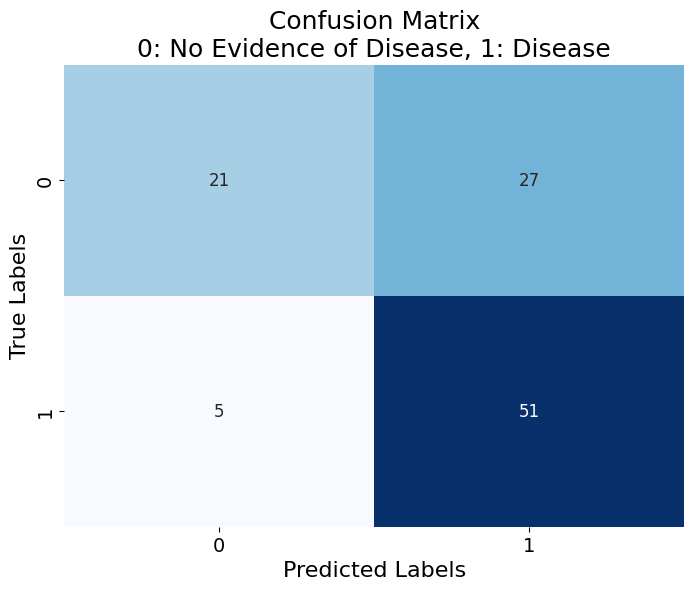

In [165]:
def confusion_df_validation(df_validation):
    conf_matrix = confusion_matrix(df_validation['real_labels'], df_validation['predicted_labels'])
    accuracy = accuracy_score(df_validation['real_labels'], df_validation['predicted_labels'])
    print(f'Accuracy: {accuracy:.2f}')
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix\n0: No Evidence of Disease, 1: Disease')
    plt.show()
confusion_df_validation(df_validation)

Brier Score - GAN (Median): 0.2444739714365203
Log Loss - GAN (Median): 0.7720822051621463
AUC-ROC - GAN (Median): 0.7005208333333333
Precision - GAN (Median): 0.6582278481012658
Recall - GAN (Median): 0.9285714285714286
F1 Score - GAN (Median): 0.7703703703703704
Accuracy - GAN (Median): 0.7019230769230769


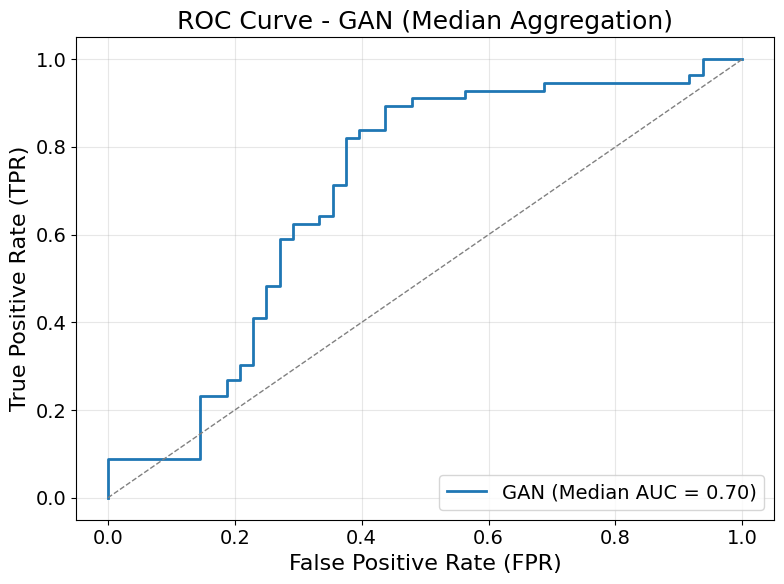

In [166]:
import numpy as np
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    accuracy_score
)
import matplotlib.pyplot as plt
import torch

def aggregate_inference(generator, data_loader, num_samples, device):
    pred_probs = []
    for _ in range(num_samples):
        noise_function = get_noise_function(config['model_config'])
        # Generate predictions with new noise each time
        pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
        pred_probs.append(pred_prob)
    return np.array(pred_probs), real_labels

def ROC_plot(generator, data_loader_val, condition):
    num_samples = 100  
    device = torch.device("cpu")  

    # Run aggregated inference
    pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

    # Aggregate probabilities (median)
    pred_probs_median = np.median(pred_probs_samples, axis=0)
    pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)


    # probs_treatments = pred_probs_median[condition].copy()
    probs_treatments = pred_probs_median.copy()
    # Brier Score
    brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

    # Log Loss
    log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

    # AUC-ROC Score
    auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

    # Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
    gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

    # Precision, Recall, F1 Score
    precision_gan = precision_score(real_labels, gan_predictions)
    recall_gan = recall_score(real_labels, gan_predictions)
    f1_gan = f1_score(real_labels, gan_predictions)

    # Accuracy
    accuracy_gan = accuracy_score(real_labels, gan_predictions)

    # Print metrics
    print("Brier Score - GAN (Median):", brier_gan)
    print("Log Loss - GAN (Median):", log_loss_gan)
    print("AUC-ROC - GAN (Median):", auc_roc_gan)
    print("Precision - GAN (Median):", precision_gan)
    print("Recall - GAN (Median):", recall_gan)
    print("F1 Score - GAN (Median):", f1_gan)
    print("Accuracy - GAN (Median):", accuracy_gan)

    # Plot ROC Curve
    fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
    roc_auc_gan = auc(fpr_gan, tpr_gan)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    plt.title('ROC Curve - GAN (Median Aggregation)')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return probs_treatments

probs_treatments =ROC_plot(generator, data_loader_val, condition)

no treatments

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-07_09-27-36_epochs_500_bs_64_lrgen_0.001_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss_v2_cGAN_v1_2/checkpoints/generator_epoch_499.pth
Brier Score - GAN (Median): 0.2444739714365203
Log Loss - GAN (Median): 0.7720822051621463
AUC-ROC - GAN (Median): 0.7005208333333333
Precision - GAN (Median): 0.6582278481012658
Recall - GAN (Median): 0.9285714285714286
F1 Score - GAN (Median): 0.7703703703703704
Accuracy - GAN (Median): 0.7019230769230769


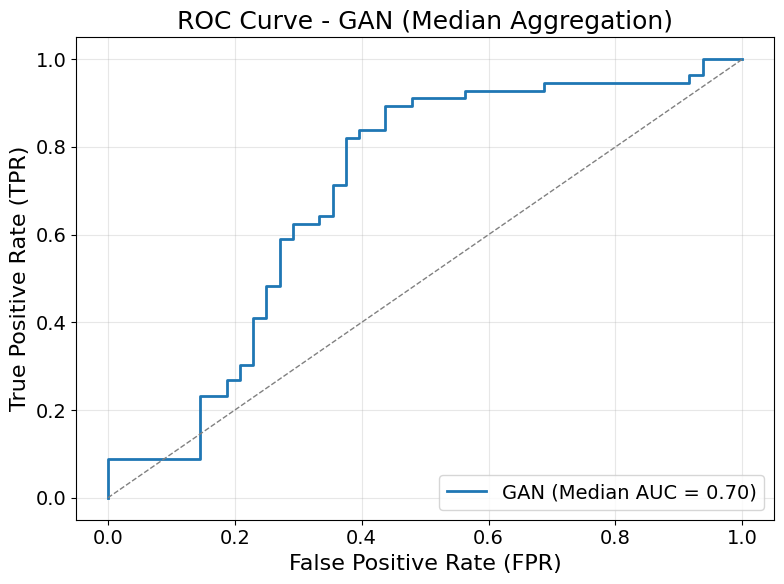

In [167]:

pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val =funtion_to_infer(config_file, model_checkpoint, validation_data_config, lantent_dim = LATENT_DIM)

df_validation  = get_validation_df(pred_labels, real_labels, features, pred_prob, scaler)



# def get_probs_treatments(generator, data_loader_val, condition):
#     def aggregate_inference(generator, data_loader, num_samples, device):
#         pred_probs = []
#         for _ in range(num_samples):
#             noise_function = get_noise_function(mc)
#             # Generate predictions with new noise each time
#             pred_labels, real_labels, features, pred_prob = inference(generator, data_loader, noise_function, device)
#             pred_probs.append(pred_prob)
#         return np.array(pred_probs), real_labels

#     # Simulated inputs (replace these with real outputs)
#     num_samples = 100  # Number of runs per data point with different noise
#     device = torch.device("cpu")  # Simulated GAN predictions

#     # Run aggregated inference
#     pred_probs_samples, real_labels = aggregate_inference(generator, data_loader_val, num_samples, device)

#     # Aggregate probabilities (median)
#     pred_probs_median = np.median(pred_probs_samples, axis=0)
#     pred_probs_median = pred_probs_median / np.sum(pred_probs_median, axis=1, keepdims=True)


#     probs_no_treatments = pred_probs_median[condition].copy()
#     # Brier Score
#     brier_gan = brier_score_loss(real_labels, pred_probs_median[:, 1])

#     # Log Loss
#     log_loss_gan = log_loss(real_labels, pred_probs_median[:, 1])

#     # AUC-ROC Score
#     auc_roc_gan = roc_auc_score(real_labels, pred_probs_median[:, 1])

#     # Convert probabilities to binary predictions based on a threshold (e.g., 0.5)
#     gan_predictions = np.argmax(np.vstack(pred_probs_median), axis=1)

#     # Precision, Recall, F1 Score
#     precision_gan = precision_score(real_labels, gan_predictions)
#     recall_gan = recall_score(real_labels, gan_predictions)
#     f1_gan = f1_score(real_labels, gan_predictions)

#     # Accuracy
#     accuracy_gan = accuracy_score(real_labels, gan_predictions)

#     # Print metrics
#     print("Brier Score - GAN (Median):", brier_gan)
#     print("Log Loss - GAN (Median):", log_loss_gan)
#     print("AUC-ROC - GAN (Median):", auc_roc_gan)
#     print("Precision - GAN (Median):", precision_gan)
#     print("Recall - GAN (Median):", recall_gan)
#     print("F1 Score - GAN (Median):", f1_gan)
#     print("Accuracy - GAN (Median):", accuracy_gan)

#     # Plot ROC Curve
#     fpr_gan, tpr_gan, _ = roc_curve(real_labels, pred_probs_median[:, 1])
#     roc_auc_gan = auc(fpr_gan, tpr_gan)

#     plt.figure(figsize=(8, 6))
#     plt.plot(fpr_gan, tpr_gan, label=f'GAN (Median AUC = {roc_auc_gan:.2f})', lw=2)
#     plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
#     plt.title('ROC Curve - GAN (Median Aggregation)')
#     plt.xlabel('False Positive Rate (FPR)')
#     plt.ylabel('True Positive Rate (TPR)')
#     plt.legend(loc='lower right')
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     return probs_no_treatments

probs_no_treatments = ROC_plot(generator, data_loader_val, condition)

surgery treatment

In [168]:
def inference_function_treatments(df, df_val, data_loader_val, config):
    dc = config['data_config']
    sgc = config['simplegan_config']
    exclude = list(set(dc['exclude_fields']) - set(dc['labels']))
    df = df.drop(columns=exclude)
    df = df.drop(columns=dc['labels'])
    sgc['input_dim'] = df.shape[1]
    mc = config['model_config']

    # Load the generator model and optimizer

    generator = SimpleGANGenerator(input_dim=sgc['input_dim'] + mc['latent_dim'], output_dim=sgc['output_dim'])

    device = torch.device('cpu')
    optimizer_gen = torch.optim.Adam(generator.parameters(), lr=0.0001)  # Use the same optimizer as during training
    generator, optimizer_gen, _, _ = load_checkpoint(model_checkpoint, generator, optimizer_gen)

    torch.manual_seed(43)
    noise_function = get_noise_function(mc)
    categorical_fields = list(set(dc['categorical_fields']) - set(dc['exclude_fields']))
    all_features = df.columns.tolist()
    numerical_fields = list(set(all_features) - set(categorical_fields) - set(dc['exclude_fields']))
    pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)
    return pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val

def preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=2):
    config = MongoExtractor.load_config(config_file)

    # Extract data configuration
    dc = config['data_config']

    # Load training data
    mongo_extractor_train = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=config_file
    )
    df = mongo_extractor_train.get_dataframe()

    # Load validation data
    mongo_extractor_val = MongoExtractor(
        connection_string=os.getenv('MONGO_URI'),
        database_name=os.getenv('MONGO_DB'),
        collection_name=os.getenv('MONGO_COLLECTION'),
        config_file=validation_data_config
    )
    df_val= mongo_extractor_val.get_dataframe()
    df_val_original = mongo_extractor_val.get_dataframe()

    dc = config['data_config']
    mc = config['model_config']
    sgc = config['simplegan_config']
    mc['latent_dim'] = 12
    mc['noise_type'] = 'uniform'
    mc['batch_size'] = 104



    df, df_val, scaler, label_encoder = preprocess_data(df, df_val, dc)


    df[columns_to_zero] = 0
    df_val[columns_to_zero] = 0
    df_val_original[columns_to_zero] = 0

    df[columns_to_one] = 1
    df_val[columns_to_one] = 1
    df_val_original[columns_to_one] = 1



    df[columns_to_value] = value
    df_val[columns_to_value] = value
    df_val_original[columns_to_value] = value


    dataset_train = EHRDataset(df)
    dataset_val = EHRDataset(df_val)

    collate_fn_dc = partial(collate_fn, dc=dc)
    data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)

    return df, df_val, data_loader_val

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-07_09-27-36_epochs_500_bs_64_lrgen_0.001_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss_v2_cGAN_v1_2/checkpoints/generator_epoch_499.pth
Brier Score - GAN (Median): 0.3243577925723798
Log Loss - GAN (Median): 0.9194518423153597
AUC-ROC - GAN (Median): 0.5915178571428571
Precision - GAN (Median): 0.9230769230769231
Recall - GAN (Median): 0.21428571428571427
F1 Score - GAN (Median): 0.34782608695652173
Accuracy - GAN (Median): 0.5673076923076923


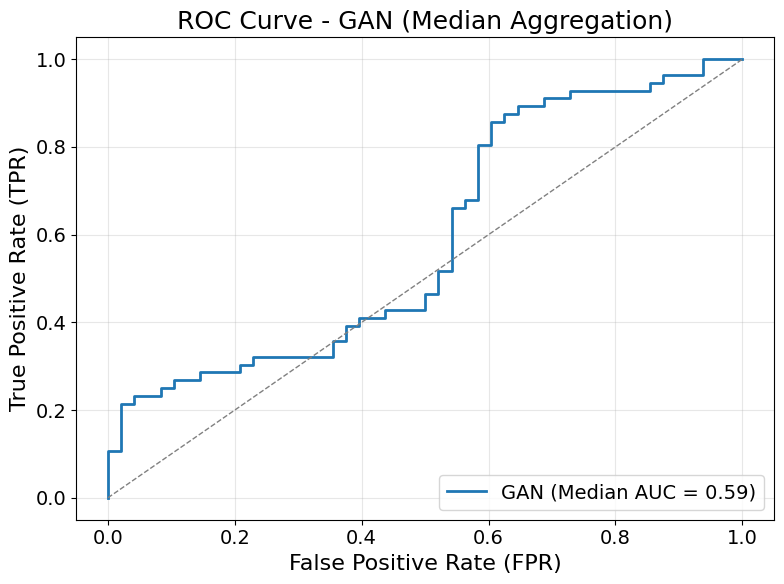

In [169]:
# SURGERY



columns_to_zero = [
        'treatment_features.chemotherapy', 
        
        'treatment_features.radiation_oncology', 
        'treatment_features.resection',
        'treatment_features.neo_adjuvant',
        
        'treatment_features.dose',
        'treatment_features.chemotherapy',
                 'treatment_features.substances_nan', 
                 'treatment_features.cycle_number']

columns_to_one =['treatment_features.surgery',
                 ] 

columns_to_value =[
                 ] 


df, df_val, data_loader_val = preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=2)

pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val =inference_function_treatments(df, df_val, data_loader_val, config)

# Convert Tensors to DataFrame

df_validation = get_validation_df(pred_labels, real_labels, features, pred_prob, scaler)



probs_surgery_treatments = ROC_plot(generator, data_loader_val, condition)

/tmp/ipykernel_247722/2479612558.py:7: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipykernel_247722/2479612558.py:8: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.


/tmp/ipykernel_247722/2479612558.py:9: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




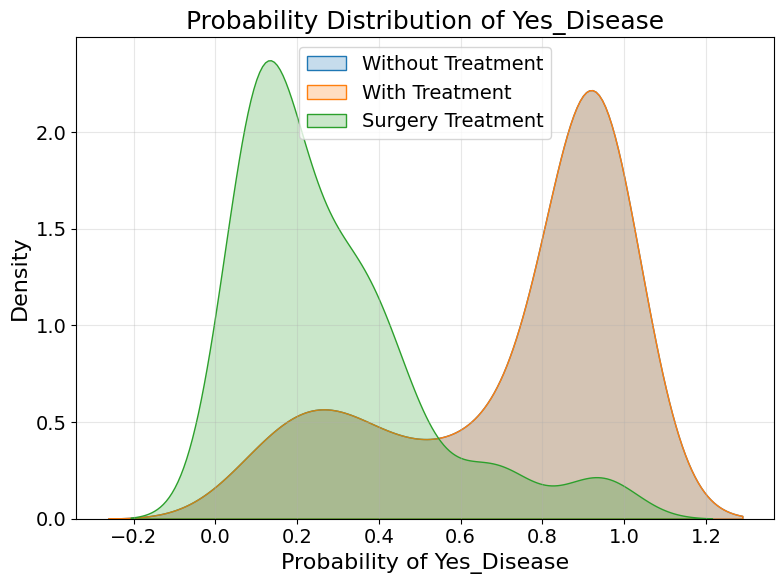

In [170]:
yes_disease_no_treatment = probs_no_treatments[:, 1]
yes_disease_treatment = probs_treatments[:, 1]
yes_disease_surgery_treatments = probs_surgery_treatments[:,1]

# Plot KDE for "yes_disease" with and without treatment
plt.figure(figsize=(8, 6))
sns.kdeplot(yes_disease_no_treatment, shade=True, label='Without Treatment', bw_adjust=1.0)
sns.kdeplot(yes_disease_treatment, shade=True, label='With Treatment', bw_adjust=1.0)
sns.kdeplot(yes_disease_surgery_treatments, shade=True, label='Surgery Treatment', bw_adjust=1.0)



# Customize the plot
plt.title('Probability Distribution of Yes_Disease')
plt.xlabel('Probability of Yes_Disease')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

radiation oncology

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-07_09-27-36_epochs_500_bs_64_lrgen_0.001_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss_v2_cGAN_v1_2/checkpoints/generator_epoch_499.pth
Brier Score - GAN (Median): 0.346696529537701
Log Loss - GAN (Median): 1.0877784756712214
AUC-ROC - GAN (Median): 0.5837053571428571
Precision - GAN (Median): 0.5684210526315789
Recall - GAN (Median): 0.9642857142857143
F1 Score - GAN (Median): 0.7152317880794702
Accuracy - GAN (Median): 0.5865384615384616


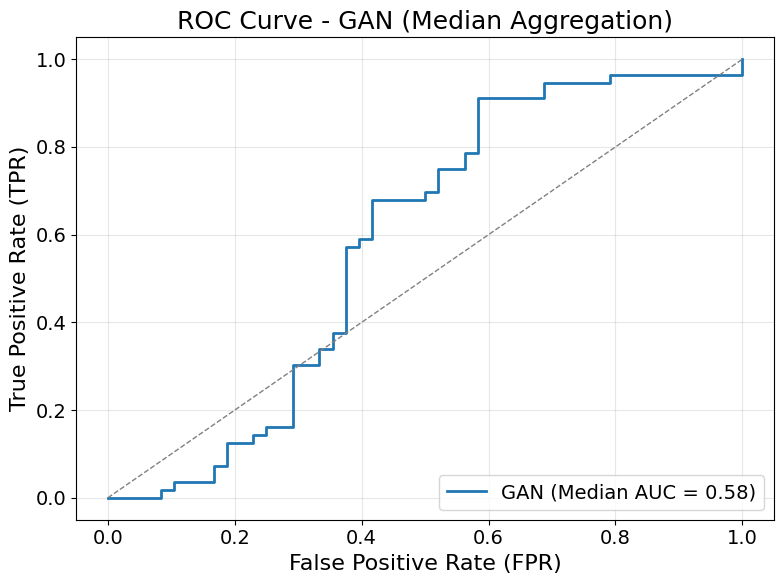

In [171]:
columns_to_zero = [
        'treatment_features.chemotherapy', 
        
    
        'treatment_features.resection',
        'treatment_features.neo_adjuvant',
        'treatment_features.chemotherapy',
                 'treatment_features.substances_nan'
        ]

columns_to_one =['treatment_features.radiation_oncology'
                 ] 


columns_to_value =['treatment_features.dose',
                 ] 

df, df_val, data_loader_val=preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=2)

pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val = inference_function_treatments(df, df_val, data_loader_val, config)
# Convert Tensors to DataFrame

df_validation = get_validation_df( pred_labels, real_labels, features, pred_prob, scaler)

probs_radiology_treatments = ROC_plot(generator, data_loader_val, condition)


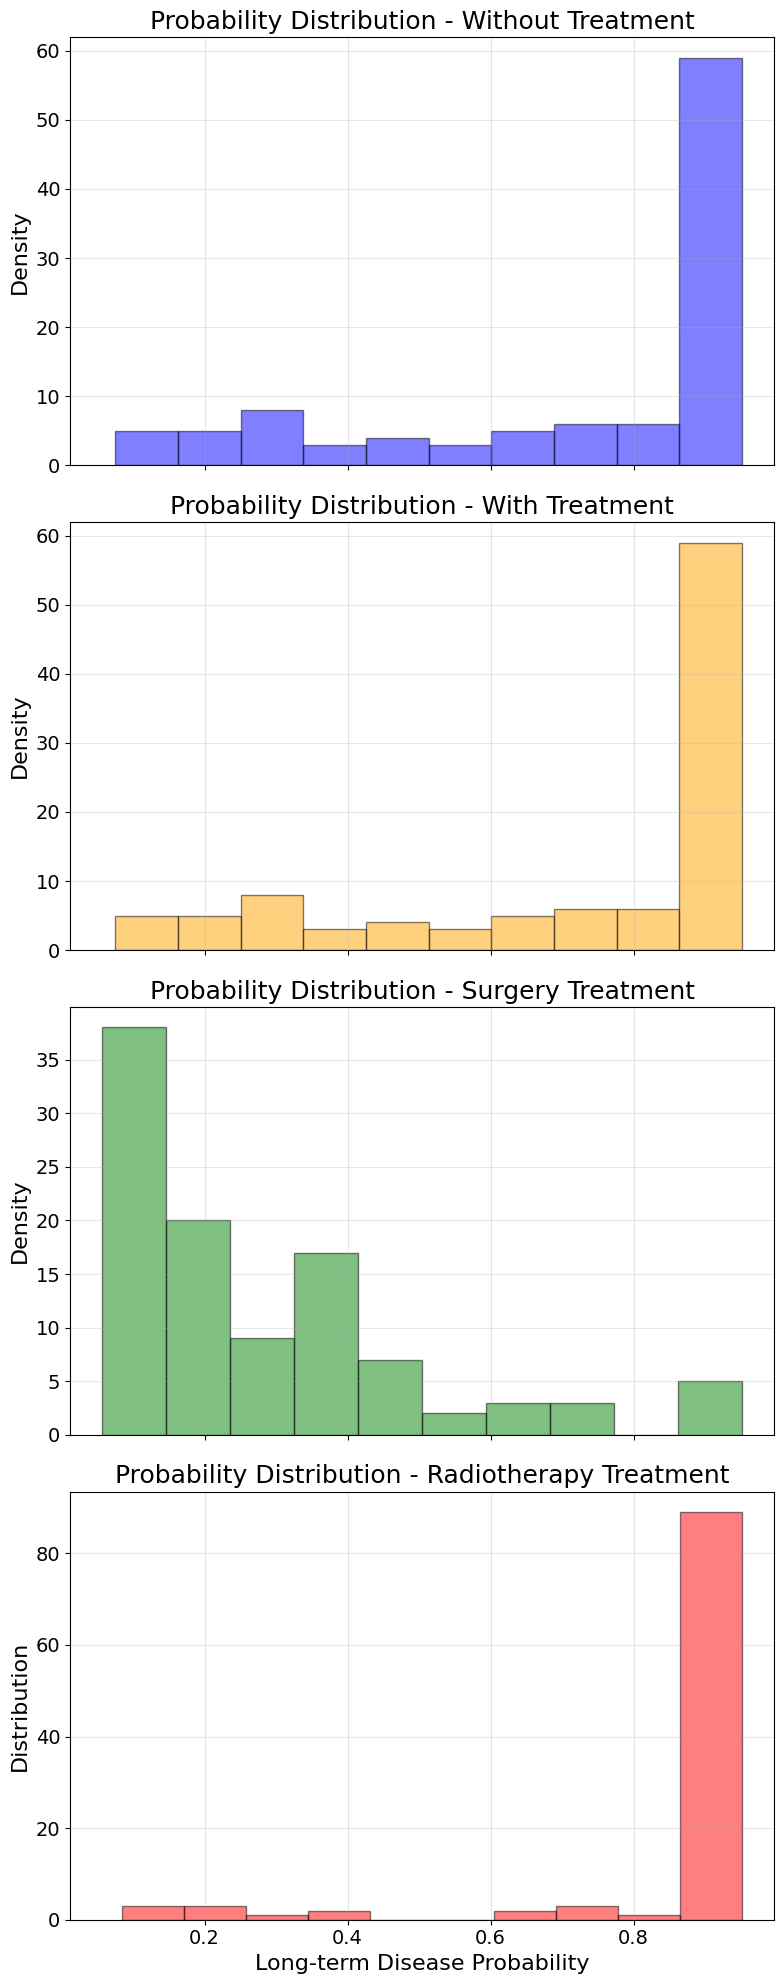

In [172]:
import numpy as np
import matplotlib.pyplot as plt

# Data for different treatments
yes_disease_no_treatment = probs_no_treatments[:, 1]
yes_disease_treatment = probs_treatments[:, 1]
yes_disease_surgery_treatments = probs_surgery_treatments[:, 1]
yes_disease_radiology_treatments = probs_radiology_treatments[:, 1]

# Define the figure with 4 rows and 1 column
fig, axes = plt.subplots(4, 1, figsize=(8, 20), sharex=True)

# Define bin edges for consistent binning across all histograms
bins =10

# Plot individual histograms on separate subplots
axes[0].hist(yes_disease_no_treatment, bins=bins, alpha=0.5, color='blue', edgecolor='black')
axes[0].set_title('Probability Distribution - Without Treatment')
axes[0].set_ylabel('Density')
axes[0].grid(alpha=0.3)

axes[1].hist(yes_disease_treatment, bins=bins,  alpha=0.5, color='orange', edgecolor='black')
axes[1].set_title('Probability Distribution - With Treatment')
axes[1].set_ylabel('Density')
axes[1].grid(alpha=0.3)

axes[2].hist(yes_disease_surgery_treatments, bins=bins, alpha=0.5, color='green', edgecolor='black')
axes[2].set_title('Probability Distribution - Surgery Treatment')
axes[2].set_ylabel('Density')
axes[2].grid(alpha=0.3)

axes[3].hist(yes_disease_radiology_treatments, bins=bins, alpha=0.5, color='red', edgecolor='black')
axes[3].set_title('Probability Distribution - Radiotherapy Treatment')
axes[3].set_xlabel('Long-term Disease Probability')
axes[3].set_ylabel('Distribution')
axes[3].grid(alpha=0.3)

# Adjust the layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


chemotherapy

Checkpoint loaded from /home/andrea/Desktop/Sarcoma-DT/Models/Models/runs/run_2024-12-07_09-27-36_epochs_500_bs_64_lrgen_0.001_lrdisc_0.0002_latent_8_optgen_adam_optdisc_adam_noise_uniform_criterion_MSELoss_v2_cGAN_v1_2/checkpoints/generator_epoch_499.pth
Brier Score - GAN (Median): 0.2497080195577026
Log Loss - GAN (Median): 0.7751278268728564
AUC-ROC - GAN (Median): 0.6975446428571429
Precision - GAN (Median): 0.6363636363636364
Recall - GAN (Median): 0.875
F1 Score - GAN (Median): 0.7368421052631579
Accuracy - GAN (Median): 0.6634615384615384


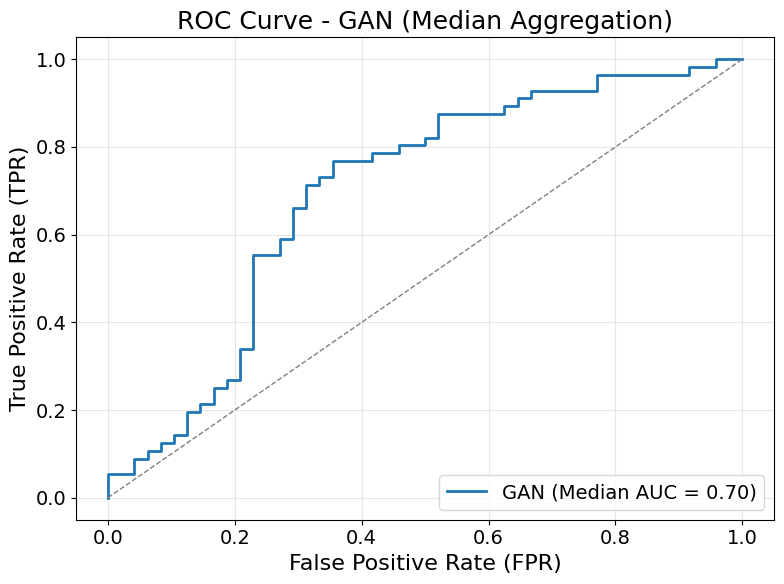

In [ ]:
columns_to_zero = [

        
        'treatment_features.radiation_oncology', 
        'treatment_features.resection',
        'treatment_features.neo_adjuvant',
        
        'treatment_features.dose',]

columns_to_one =['treatment_features.cycle_number'
                 ] 


columns_to_value =['treatment_features.chemotherapy',
                 'treatment_features.substances_nan'
                 ] 

df, df_val, data_loader_val=preprocess_treatment(columns_to_one, columns_to_zero, columns_to_value, value=0.5)



pred_labels, real_labels, features, pred_prob, scaler, config, generator, data_loader_val = inference_function_treatments(df, df_val, data_loader_val, config)
# Convert Tensors to DataFrame

df_validation = get_validation_df( pred_labels, real_labels, features, pred_prob, scaler)

probs_chemotherapy_treatments = ROC_plot(generator, data_loader_val, condition)


/tmp/ipykernel_247722/3213298516.py:14: FutureWarning:



`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.




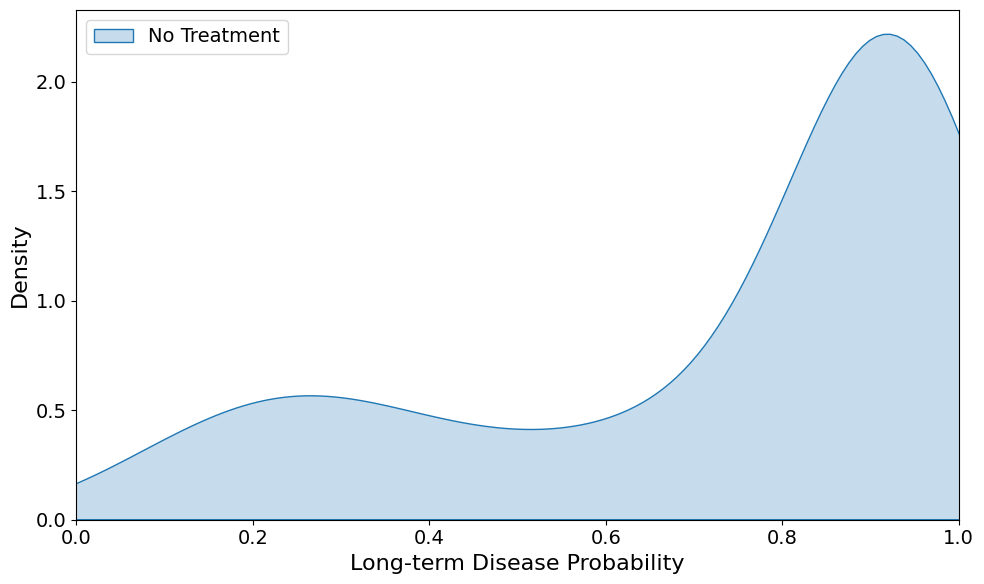

In [174]:
yes_disease_no_treatment = probs_no_treatments[:, 1]
yes_disease_treatment = probs_treatments[:, 1]
yes_disease_surgery_treatments = probs_surgery_treatments[:,1]
yes_disease_radiology_treatments= probs_radiology_treatments[:,1]
yes_disease_chemotherapy_treatments =probs_chemotherapy_treatments[:,1]


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Adjust bandwidth and plot KDEs
sns.kdeplot(yes_disease_no_treatment, shade=True, label='No Treatment', bw_adjust=1.0, common_norm=False)
# sns.kdeplot(yes_disease_surgery_treatments, shade=True, label='Surgery', bw_adjust=0.8)
# sns.kdeplot(yes_disease_radiology_treatments, shade=True, label='Radiotherapy', bw_adjust=0.8)
# sns.kdeplot(yes_disease_chemotherapy_treatments, shade=True, label='Chemotherapy', bw_adjust=0.8)

# Set X-axis limit to reasonable values
plt.xlim([0, 1])  # Adjust the range as per your data to keep it reasonable
plt.xlabel('Long-term Disease Probability')
plt.ylabel('Density')
# plt.title('Density Plot of Treatments')
plt.legend()
plt.tight_layout()
plt.show()


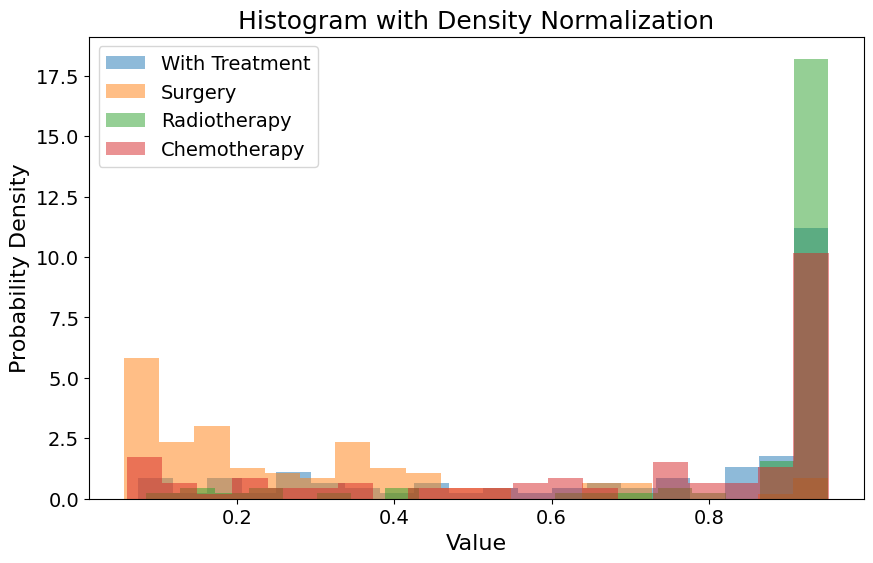

In [175]:
plt.figure(figsize=(10, 6))
plt.hist(yes_disease_treatment, bins=20, density=True, alpha=0.5, label='With Treatment')
plt.hist(yes_disease_surgery_treatments, bins=20, density=True, alpha=0.5, label='Surgery')
plt.hist(yes_disease_radiology_treatments, bins=20, density=True, alpha=0.5, label='Radiotherapy')
plt.hist(yes_disease_chemotherapy_treatments, bins=20, density=True, alpha=0.5, label='Chemotherapy')

plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Histogram with Density Normalization')
plt.legend()
plt.show()


/tmp/ipykernel_247722/2429796759.py:40: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.

/tmp/ipykernel_247722/2429796759.py:40: FutureWarning:



The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.5`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.




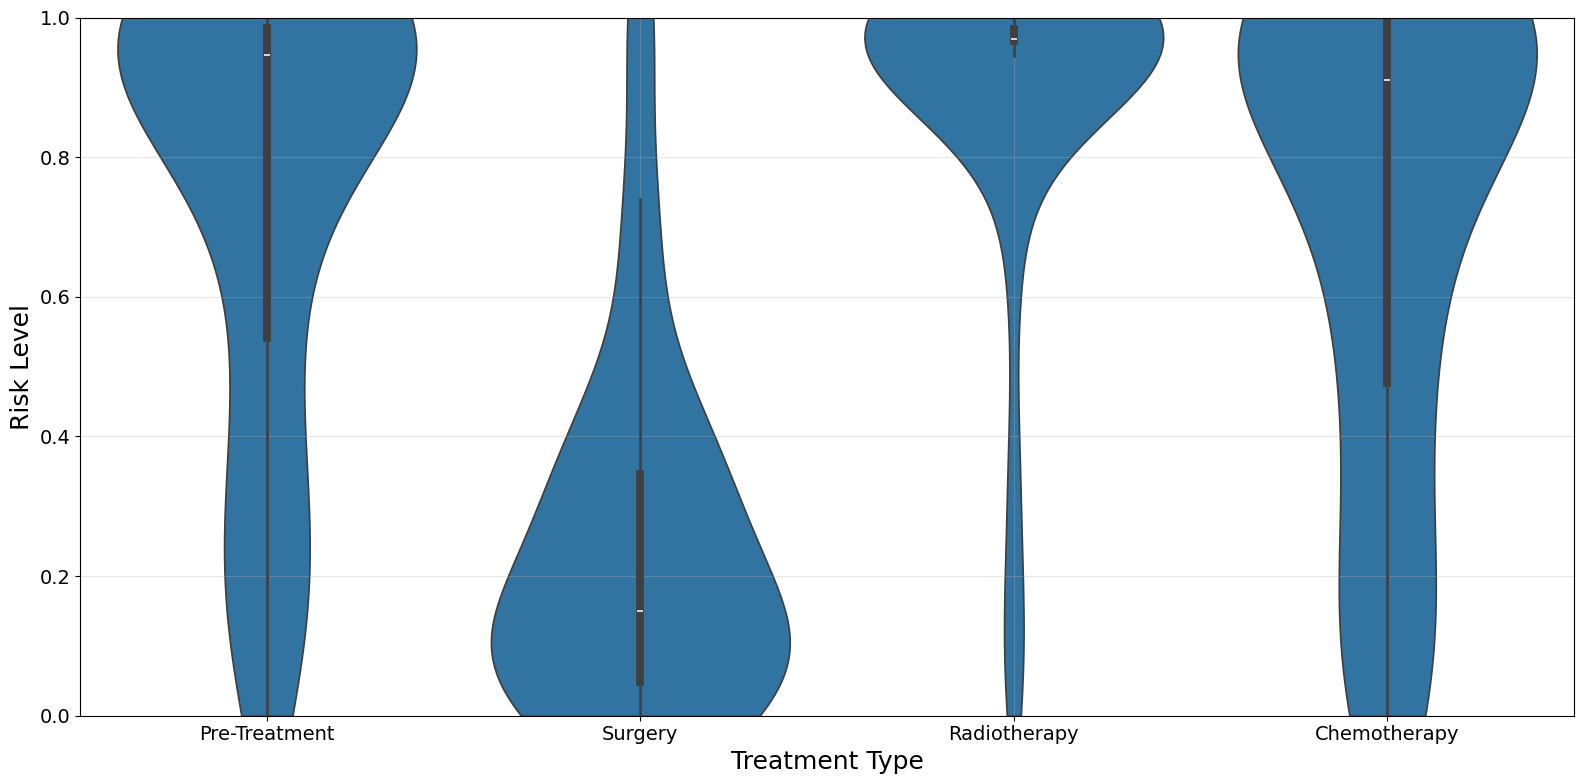

In [176]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Function to normalize data to the range [0, 1]
def normalize_data(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data))

# Normalize the data for each treatment
yes_disease_no_treatment = normalize_data(probs_no_treatments[:, 1])
yes_disease_treatment = normalize_data(probs_treatments[:, 1])
yes_disease_surgery_treatments = normalize_data(probs_surgery_treatments[:, 1])
yes_disease_radiology_treatments = normalize_data(probs_radiology_treatments[:, 1])
yes_disease_chemotherapy_treatments = normalize_data(probs_chemotherapy_treatments[:, 1])

# Create a dictionary for the data and categories
data_dict = {
    'Pre-Treatment': yes_disease_no_treatment,
    'Surgery': yes_disease_surgery_treatments,
    'Radiotherapy': yes_disease_radiology_treatments,
    'Chemotherapy': yes_disease_chemotherapy_treatments
}

# Prepare data for a single seaborn plot
plot_data = pd.concat(
    [pd.DataFrame({'Value': values, 'Category': category}) for category, values in data_dict.items()]
)

# Set font sizes globally
plt.rc('axes', titlesize=18)    # Font size for titles
plt.rc('axes', labelsize=16)    # Font size for x and y labels
plt.rc('xtick', labelsize=14)   # Font size for x-axis ticks
plt.rc('ytick', labelsize=14)   # Font size for y-axis ticks
plt.rc('legend', fontsize=14)   # Font size for legend
plt.rc('font', size=12)         # General font size

# Create the violin plots horizontally
plt.figure(figsize=(16, 8))
sns.violinplot(x='Category', y='Value', data=plot_data, bw=0.5, scale='width', cut=0)

# Set plot title and axis labels
# plt.title('Probability Distribution by Treatment Type (Normalized to [0, 1])', fontsize=20)
plt.xlabel('Treatment Type', fontsize=18)
plt.ylabel('Risk Level', fontsize=18)
plt.ylim(0, 1)  # Ensure the y-axis is between 0 and 1
plt.grid(alpha=0.3)

# Show the plot
plt.tight_layout()
plt.show()



In [177]:
# Define the ranges for sensitivity analysis
dose_range = range(1, 5)  # Example range of dose values
fractions_range = range(1, 5)  # Example range for number of fractions

# DataFrame to store results
sensitivity_results = []

for dose in dose_range:
    
    # Update DataFrames with the current dose and fractions
    df['treatment_features.dose'] = dose
    df['treatment_features.number_fractions'] = dose
    df_val['treatment_features.dose'] = dose
    df_val['treatment_features.number_fractions'] = dose
    mc = config['model_config']
    # Update the datasets and dataloaders
    dataset_val = EHRDataset(df_val)
    collate_fn_dc = partial(collate_fn, dc=config['data_config'])
    data_loader_val = DataLoader(dataset_val, batch_size=mc['batch_size'], drop_last=True, collate_fn=collate_fn_dc)
    noise_function = get_noise_function(mc)
    device = torch.device('cpu')
    # Perform inference
    pred_labels, real_labels, features, pred_prob = inference(generator, data_loader_val, noise_function, device)
    
    # Aggregate results
    for idx, prob in enumerate(pred_prob):
        result = {
            'dose': dose,
            'number_fractions': dose,
            'real_label': real_labels[idx],
            'predicted_label': pred_labels[idx],
            'probability_no_disease': prob[0],
            'probability_yes_disease': prob[1]
        }
        sensitivity_results.append(result)

# Convert results to a DataFrame for analysis
sensitivity_df = pd.DataFrame(sensitivity_results)

# Save or display results
sensitivity_df.to_csv("sensitivity_analysis_results.csv", index=False)
print(sensitivity_df.head())


   dose  number_fractions  real_label  predicted_label  \
0     1                 1           0                0   
1     1                 1           1                0   
2     1                 1           0                0   
3     1                 1           0                0   
4     1                 1           1                1   

   probability_no_disease  probability_yes_disease  
0                0.125188                 0.049888  
1                0.969057                 0.103697  
2                0.382173                 0.101930  
3                0.975385                 0.227606  
4                0.040007                 0.732914  


/tmp/ipykernel_247722/2893258661.py:8: FutureWarning:



The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.

/tmp/ipykernel_247722/2893258661.py:8: FutureWarning:



The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.5`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.




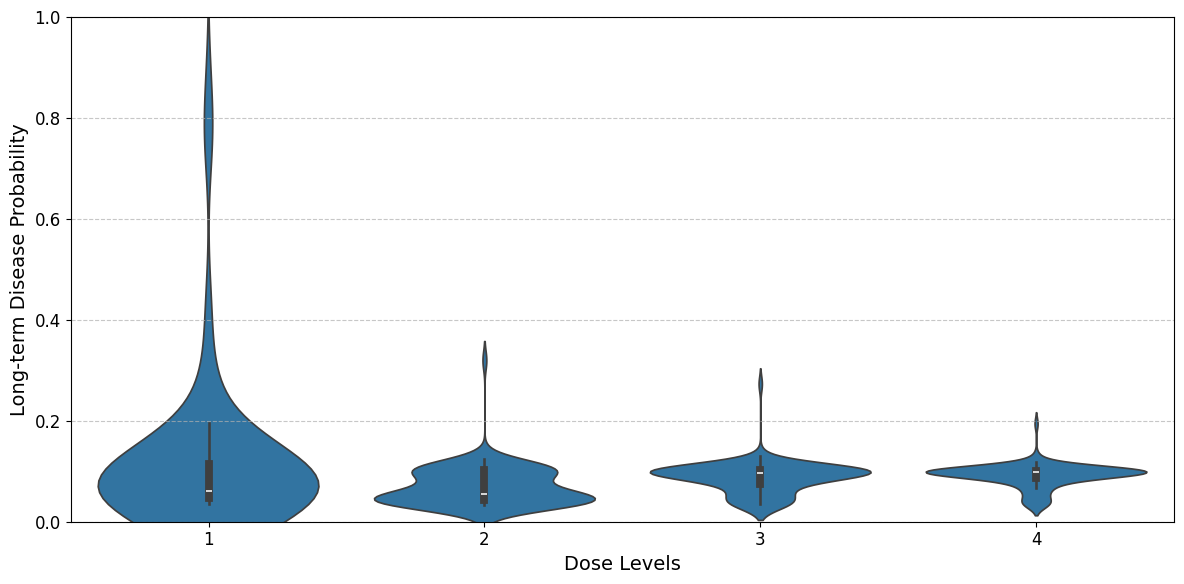

In [178]:
# Assuming `sensitivity_df` is already available in memory from the previous script
# Filter and organize data for plotting
sensitivity_df['dose'] = sensitivity_df['dose'].astype(int)
sensitivity_df['probability_yes_disease'] = sensitivity_df['probability_yes_disease'].astype(float)

# Create a violin plot for the predicted probability vs. dose levels
plt.figure(figsize=(12, 6))
sns.violinplot(
    x="dose",
    y="probability_yes_disease",
    data=sensitivity_df,
    # palette="viridis",
    bw=0.5,
    # inner="quartile"
    scale="width"
)
# plt.title("Violin Plot of Predicted Probabilities by Dose Levels", fontsize=16)
plt.xlabel("Dose Levels", fontsize=14)
plt.ylabel('Long-term Disease Probability', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1) 
# Show the plot
plt.tight_layout()
plt.show()


In [179]:
medians = {
    'Pre-Treatment': np.median(yes_disease_no_treatment),
    'Surgery': np.median(yes_disease_surgery_treatments),
    'Radiotherapy': np.median(yes_disease_radiology_treatments),
    'Chemotherapy': np.median(yes_disease_chemotherapy_treatments)
}

medians

{'Pre-Treatment': 0.94606394,
 'Surgery': 0.14959046,
 'Radiotherapy': 0.9695202,
 'Chemotherapy': 0.9105632}

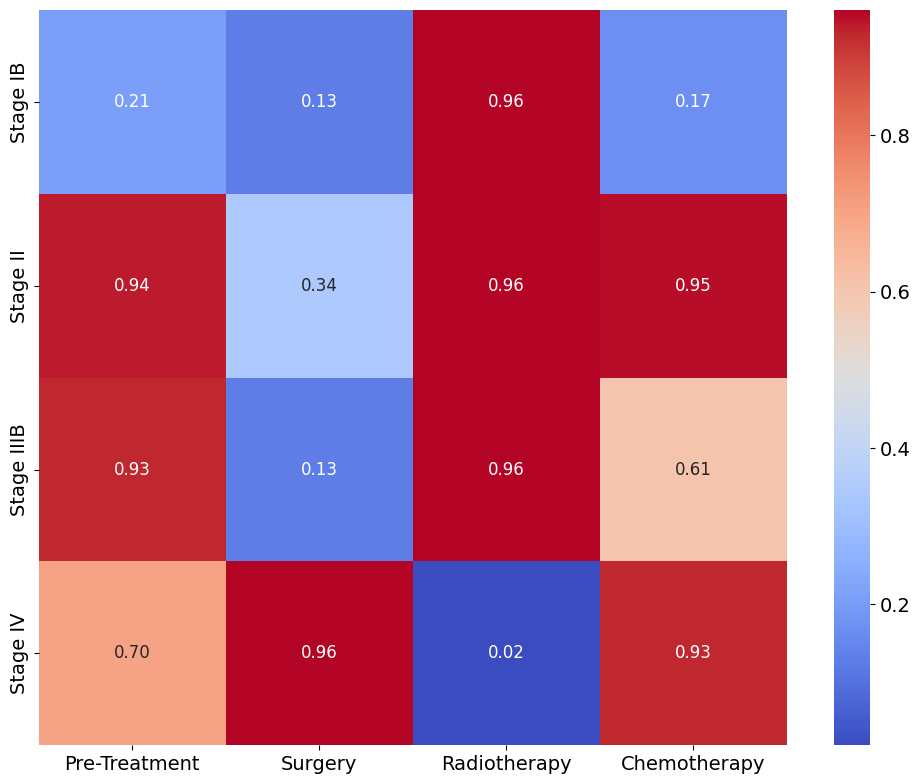

In [180]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a 2D dictionary for medians (fill in the values manually)
medians = {
    'Stage IB': {
        'Pre-Treatment': 0.21,  # Add the median value here
        'Surgery': 0.13,           # Add the median value here
        'Radiotherapy': 0.96,      # Add the median value here
        'Chemotherapy': 0.17       # Add the median value here
    },

    'Stage II': {
        'Pre-Treatment': 0.94,  # Add the median value here
        'Surgery': 0.34,           # Add the median value here
        'Radiotherapy': 0.96,      # Add the median value here
        'Chemotherapy': 0.95       # Add the median value here
    },
    'Stage IIIB': {
        'Pre-Treatment': 0.93,  # Add the median value here
        'Surgery': 0.13,           # Add the median value here
        'Radiotherapy': 0.96,      # Add the median value here
        'Chemotherapy': 0.61       # Add the median value here
    },
    'Stage IV': {
        'Pre-Treatment': 0.70,  # Add the median value here
        'Surgery': 0.96,           # Add the median value here
        'Radiotherapy': 0.02,      # Add the median value here
        'Chemotherapy': 0.93       # Add the median value here
    }
}

# Convert the dictionary into a DataFrame for the heatmap
heatmap_data = pd.DataFrame(medians).T  # Transpose to align stages (rows) and treatments (columns)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title('')
plt.ylabel('')
plt.xlabel('')
plt.tight_layout()
plt.show()


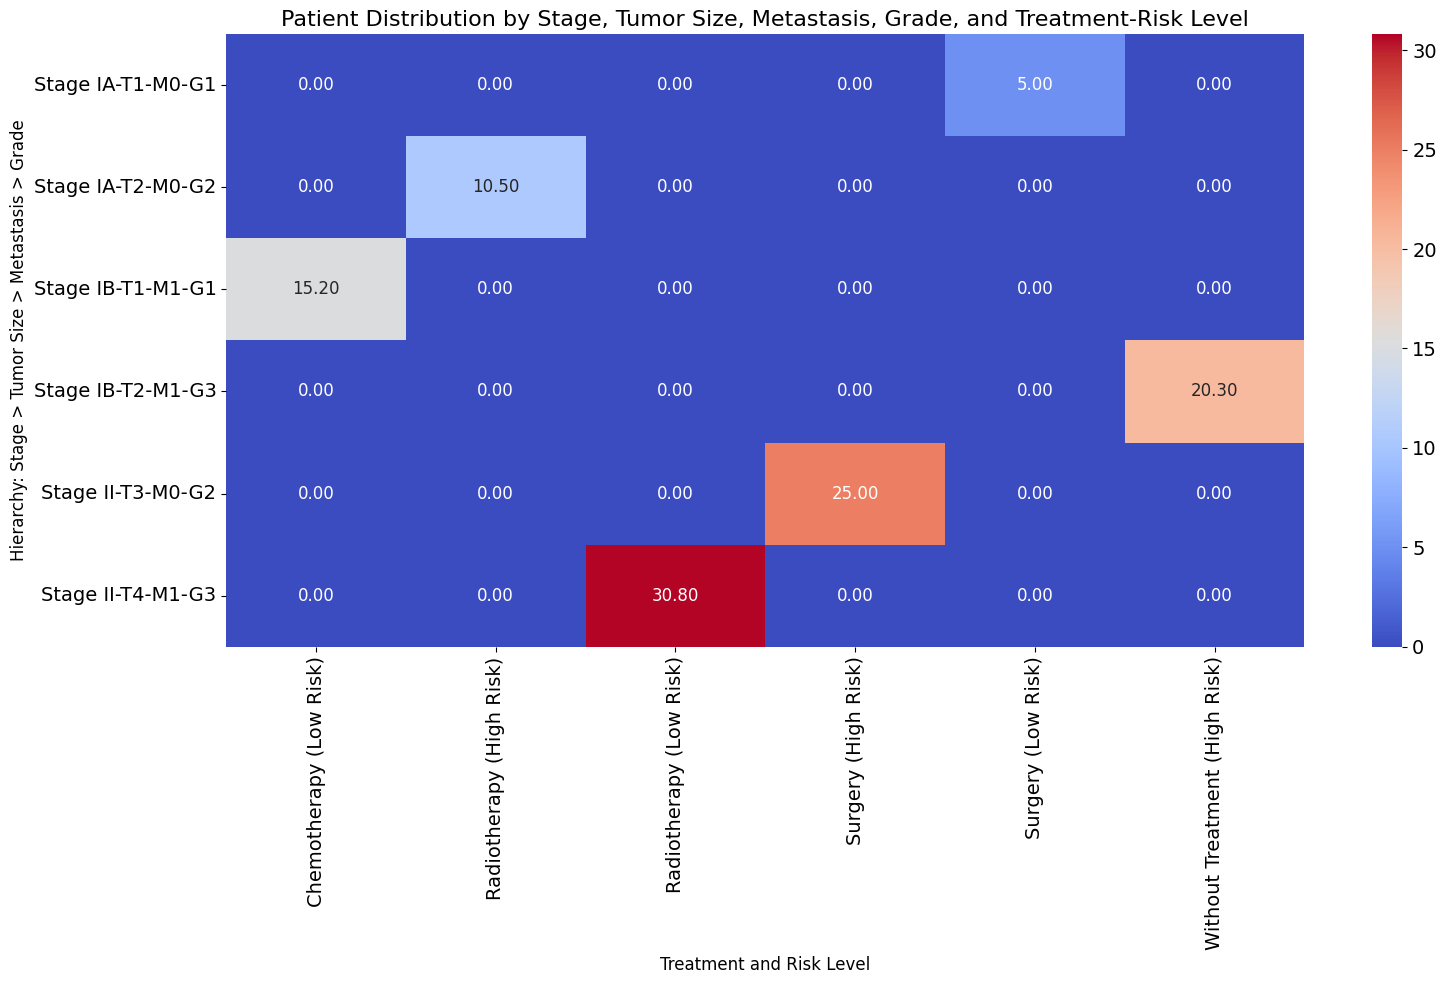

In [181]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example simulated data (replace with your actual dataset)
data = {
    'Stage': ['Stage IA', 'Stage IA', 'Stage IB', 'Stage IB', 'Stage II', 'Stage II'],
    'Tumor Size': ['T1', 'T2', 'T1', 'T2', 'T3', 'T4'],
    'Metastasis': ['M0', 'M0', 'M1', 'M1', 'M0', 'M1'],
    'Grade': ['G1', 'G2', 'G1', 'G3', 'G2', 'G3'],
    'Treatment': ['Surgery', 'Radiotherapy', 'Chemotherapy', 'Without Treatment', 'Surgery', 'Radiotherapy'],
    'Risk Level': ['Low Risk', 'High Risk', 'Low Risk', 'High Risk', 'High Risk', 'Low Risk'],
    'Count': [5.0, 10.5, 15.2, 20.3, 25.0, 30.8]  # Example float counts
}

# Convert data to a DataFrame
df = pd.DataFrame(data)

# Create a combined column for Treatment and Risk Level
df['Treatment_Risk'] = df['Treatment'] + ' (' + df['Risk Level'] + ')'

# Pivot the data for hierarchical heatmap
pivot_data = df.pivot_table(
    index=['Stage', 'Tumor Size', 'Metastasis', 'Grade'],  # Hierarchy for Y-axis
    columns='Treatment_Risk',  # Columns for Treatment and Risk Level
    values='Count',  # Values to populate cells
    fill_value=0
)

# Plot the hierarchical heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".2f",  # Format numbers as floats with two decimal places
    cmap="coolwarm",
    cbar=True
)
plt.title('Patient Distribution by Stage, Tumor Size, Metastasis, Grade, and Treatment-Risk Level', fontsize=16)
plt.ylabel('Hierarchy: Stage > Tumor Size > Metastasis > Grade', fontsize=12)
plt.xlabel('Treatment and Risk Level', fontsize=12)
plt.tight_layout()
plt.show()




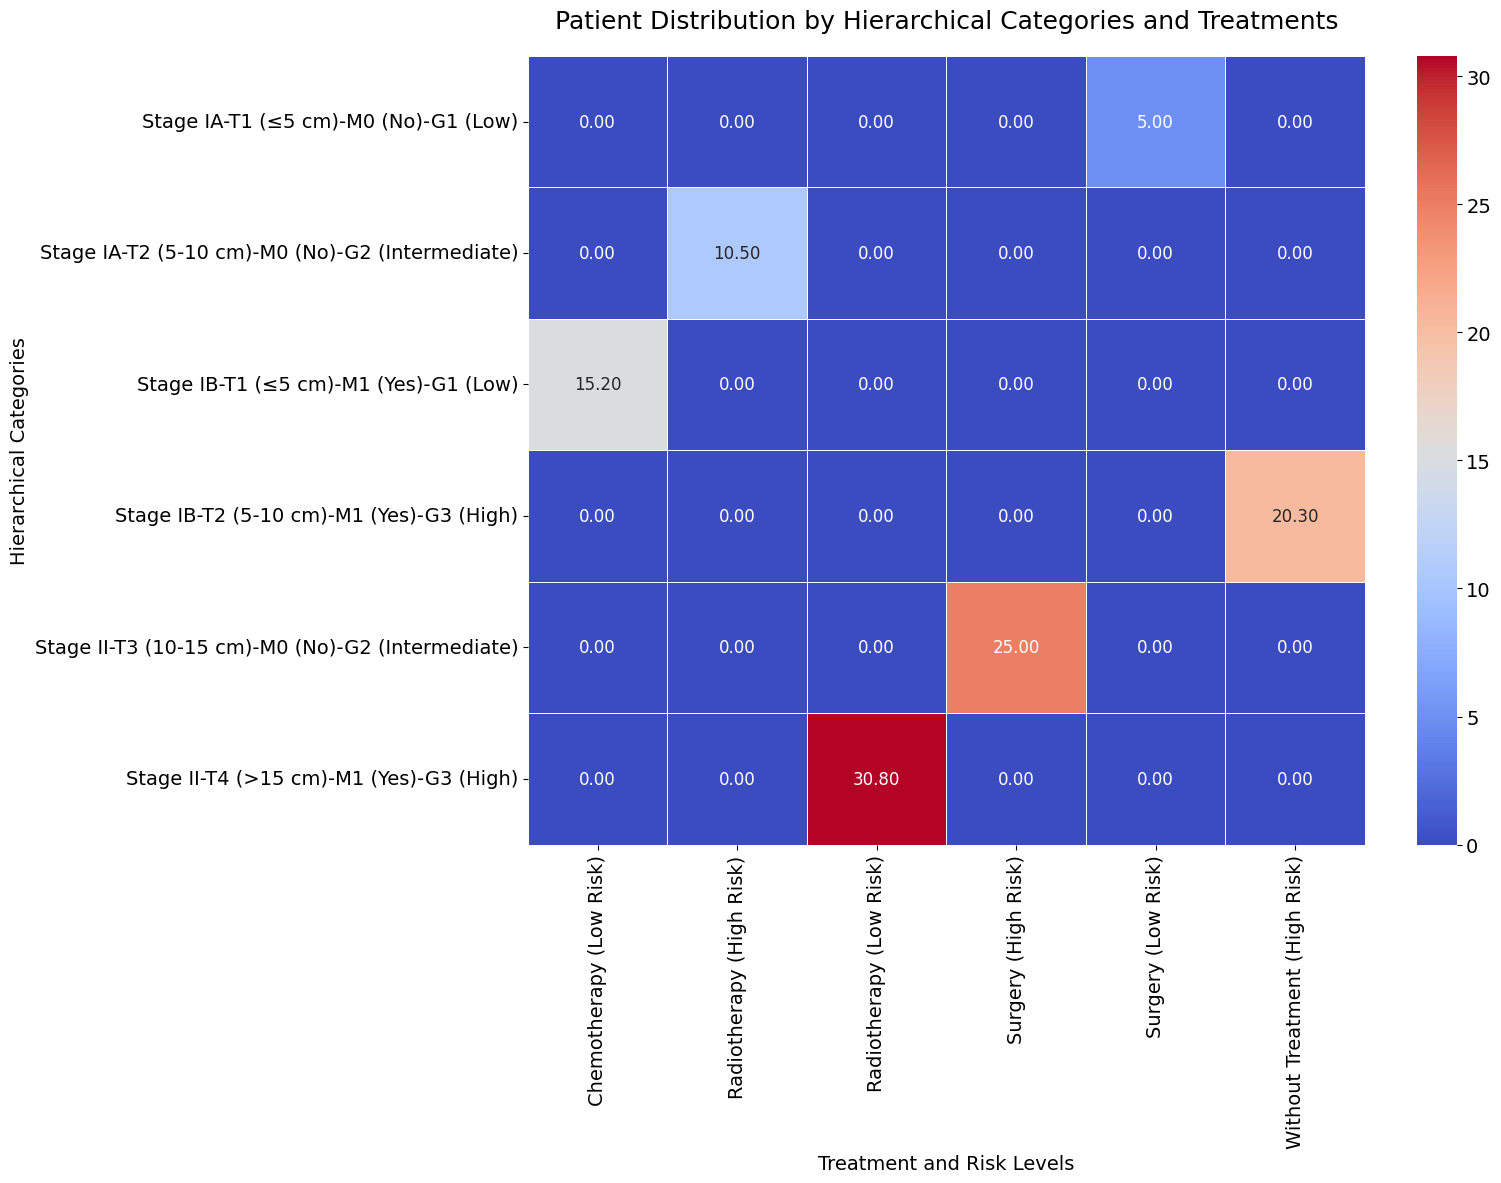

In [182]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Example data (replace with your actual dataset)
data = {
    'Stage': ['Stage IA', 'Stage IA', 'Stage IB', 'Stage IB', 'Stage II', 'Stage II'],
    'Tumor Size': ['T1 (≤5 cm)', 'T2 (5-10 cm)', 'T1 (≤5 cm)', 'T2 (5-10 cm)', 'T3 (10-15 cm)', 'T4 (>15 cm)'],
    'Metastasis': ['M0 (No)', 'M0 (No)', 'M1 (Yes)', 'M1 (Yes)', 'M0 (No)', 'M1 (Yes)'],
    'Grade': ['G1 (Low)', 'G2 (Intermediate)', 'G1 (Low)', 'G3 (High)', 'G2 (Intermediate)', 'G3 (High)'],
    'Treatment': ['Surgery', 'Radiotherapy', 'Chemotherapy', 'Without Treatment', 'Surgery', 'Radiotherapy'],
    'Risk Level': ['Low Risk', 'High Risk', 'Low Risk', 'High Risk', 'High Risk', 'Low Risk'],
    'Count': [5.0, 10.5, 15.2, 20.3, 25.0, 30.8]  # Example counts
}

# Convert data to a DataFrame
df = pd.DataFrame(data)

# Create a combined column for hierarchical indexing
df['Hierarchy'] = (
    df['Stage'] + ' > ' +
    df['Tumor Size'] + ' > ' +
    df['Metastasis'] + ' > ' +
    df['Grade']
)

# Create a combined column for Treatment and Risk Level
df['Treatment_Risk'] = df['Treatment'] + ' (' + df['Risk Level'] + ')'

# Pivot the data to organize counts hierarchically
pivot_data = df.pivot_table(
    index='Hierarchy',  # Hierarchical Y-axis
    columns='Treatment_Risk',  # Treatments with Risk Levels
    values='Count',  # Values for heatmap
    fill_value=0
)

# Split the hierarchical index back into individual components for better visualization
pivot_data.index = pivot_data.index.str.split(' > ', expand=True)
pivot_data.index.names = ['Stage', 'Tumor Size', 'Metastasis', 'Grade']

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    pivot_data,
    annot=True,
    fmt=".2f",  # Format as floats
    cmap="coolwarm",
    cbar=True,
    linewidths=0.5  # Add gridlines for clarity
)

# Add custom labels
plt.title('Patient Distribution by Hierarchical Categories and Treatments', fontsize=18, pad=20)
plt.ylabel('Hierarchical Categories', fontsize=14)
plt.xlabel('Treatment and Risk Levels', fontsize=14)

# Adjust layout for clarity
plt.tight_layout()
plt.show()


In [183]:
import plotly.express as px

# Using the same data as above
fig = px.treemap(
    df,
    path=['Stage', 'Tumor Size', 'Metastasis', 'Grade', 'Treatment', 'Risk Level'],  # Hierarchy levels
    values='Count',  # Size of each block
    color='Treatment',  # Color blocks by Treatment
    title="Patient Distribution Treemap",
    width=800,
    height=800
)

# Show the Treemap
fig.show()


In [184]:
import plotly.graph_objects as go

# Define the nodes in the hierarchy
nodes = [
    'Stage IA', 'T1 (≤5 cm)', 'T2 (5-10 cm)',  # Stage and Tumor Sizes
    'No Metastasis (M0)', 'Metastasis Present (M1)',  # Metastasis
    'Low Grade (G1)', 'High Grade (G3)',  # Grades
    'Surgery (Low Risk)', 'Radiotherapy (High Risk)'  # Treatments
]

# Define links between nodes
links = dict(
    source=[0, 0, 1, 1, 2, 2, 3, 4],  # Source node indices
    target=[1, 2, 3, 4, 5, 6, 7, 8],  # Target node indices
    value=[30, 20, 10, 15, 5, 10, 10, 15]  # Patient counts for each path
)

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display
fig.update_layout(title_text="Hierarchical Decision Tree Representation (Sankey Diagram)", font_size=10)
fig.show()



In [185]:
import plotly.graph_objects as go

# Define the nodes (stages, treatments, and risk categories)
nodes = [
    'Stage IA High Risk', 'Stage IA Low Risk',  # Initial risk categories for Stage IA
    'Surgery', 'Radiotherapy', 'Chemotherapy',  # Treatment nodes
    'Stage IB High Risk', 'Stage IB Low Risk',  # Risk categories after treatment for Stage IB
    'Stage II High Risk', 'Stage II Low Risk'   # Risk categories after treatment for Stage II
]

# Define the links (transitions between nodes)
links = dict(
    source=[
        0, 0,  # Stage IA High Risk transitions to treatments
        1, 1,  # Stage IA Low Risk transitions to treatments
        2, 2, 2,  # Surgery outcomes (to High/Low Risk for Stage IB and Stage II)
        3, 3, 3,  # Radiotherapy outcomes
        4, 4, 4   # Chemotherapy outcomes
    ],
    target=[
        2, 3,  # Stage IA High Risk -> Surgery, Radiotherapy
        2, 4,  # Stage IA Low Risk -> Surgery, Chemotherapy
        5, 6, 7,  # Surgery -> High/Low Risk (Stage IB/II)
        5, 6, 8,  # Radiotherapy -> High/Low Risk (Stage IB/II)
        7, 8, 6   # Chemotherapy -> High/Low Risk (Stage IB/II)
    ],
    value=[
        30, 20,  # Stage IA High Risk -> Surgery, Radiotherapy
        10, 15,  # Stage IA Low Risk -> Surgery, Chemotherapy
        20, 10, 5,  # Surgery -> Stage IB/II High/Low Risk
        15, 10, 5,  # Radiotherapy -> Stage IB/II High/Low Risk
        10, 15, 5   # Chemotherapy -> Stage IB/II High/Low Risk
    ]
)

# Create Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display the diagram
fig.update_layout(
    title_text="Patient Category Transitions by Treatment",
    font_size=12
)

fig.show()


In [186]:
import plotly.graph_objects as go

# Nodes in the hierarchy
nodes = [
    'Stage IA', 
    'T1 (≤5 cm)', 'T2 (5-10 cm)',  # Tumor size categories
    'No Metastasis (M0)', 'Metastasis Present (M1)',  # Metastasis categories
    'Low Grade (G1)', 'High Grade (G3)',  # Grade categories
    'High Risk', 'Low Risk'  # Risk levels
]

# Links between nodes (source → target) with patient counts
links = dict(
    source=[
        0, 0,  # Stage IA → Tumor Size (T1, T2)
        1, 1, 2, 2,  # Tumor Size → Metastasis (M0, M1)
        3, 3, 4, 4,  # Metastasis → Grade (G1, G3)
        5, 5, 6, 6   # Grade → Risk Level (High, Low)
    ],
    target=[
        1, 2,  # Stage IA → Tumor Size (T1, T2)
        3, 4, 3, 4,  # Tumor Size → Metastasis (M0, M1)
        5, 6, 5, 6,  # Metastasis → Grade (G1, G3)
        7, 8, 7, 8   # Grade → Risk Level (High, Low)
    ],
    value=[
        50, 30,  # Patients from Stage IA → Tumor Sizes
        40, 10, 20, 10,  # Tumor Sizes → Metastasis
        15, 25, 10, 20,  # Metastasis → Grade
        20, 20, 15, 25   # Grade → Risk Levels
    ]
)

# Create Sankey Diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display
fig.update_layout(
    title_text="Patient Flow: Stage IA → Risk Levels via Tumor Size, Metastasis, and Grade",
    font_size=12
)

fig.show()


In [187]:
df_validation.columns


Index(['initial_diagnosis.initial_size_a', 'initial_diagnosis.initial_size_b',
       'initial_diagnosis.initial_size_c', 'patient_info.age_at_admission',
       'treatment_features.surgery', 'treatment_features.max_dimension',
       'treatment_features.complexity_number',
       'treatment_features.chemotherapy', 'treatment_features.cycle_number',
       'treatment_features.radiation_oncology', 'treatment_features.dose',
       'treatment_features.number_fractions', 'treatment_features.ptv_volume',
       'treatment_features.gtv_volume', 'treatment_features.resection',
       'treatment_features.neo_adjuvant',
       'treatment_features.closest_distance',
       'initial_diagnosis.first_anatomic_region_code_grouping_B',
       'initial_diagnosis.first_anatomic_region_code_grouping_D',
       'initial_diagnosis.first_anatomic_region_code_grouping_S',
       'initial_diagnosis.first_diagnosis_malignant_benign_2.0',
       'initial_diagnosis.first_diagnosis_malignant_benign_3.0',
      

In [188]:
import plotly.graph_objects as go

# Nodes for the hierarchy (specific to "Surgery")
nodes = [
    'Stage IA',  # Stage
    'T1 (≤5 cm)', 'T2 (5-10 cm)',  # Tumor Size
    'No Metastasis (M0)', 'Metastasis Present (M1)',  # Metastasis
    'Low Grade (G1)', 'High Grade (G3)',  # Histologic Grade
    'High Risk', 'Low Risk'  # Risk Levels
]

# Links for "Surgery" treatment
links = dict(
    source=[
        0, 0,  # Stage IA → Tumor Sizes
        1, 1, 2, 2,  # Tumor Size → Metastasis
        3, 3, 4, 4,  # Metastasis → Grade
        5, 5, 6, 6   # Grade → Risk Levels
    ],
    target=[
        1, 2,  # Stage IA → Tumor Sizes
        3, 4, 3, 4,  # Tumor Size → Metastasis
        5, 6, 5, 6,  # Metastasis → Grade
        7, 8, 7, 8   # Grade → Risk Levels
    ],
    value=[
        40, 20,  # Stage IA → Tumor Sizes
        30, 10, 15, 5,  # Tumor Sizes → Metastasis
        10, 15, 5, 10,  # Metastasis → Grade
        5, 15, 10, 20   # Grade → Risk Levels
    ]
)

# Create Sankey Diagram for "Surgery"
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=links
))

# Add title and display
fig.update_layout(
    title_text="Patient Flow for Surgery: Stage → Tumor Size → Metastasis → Grade → Risk Level",
    font_size=12
)

fig.show()


In [189]:
df_validation['staging']

0      Stage IIIA
1        Stage II
2        Stage II
3        Stage IB
4        Stage IV
          ...    
99     Stage IIIB
100      Stage II
101    Stage IIIA
102      Stage IA
103      Stage II
Name: staging, Length: 104, dtype: object

In [197]:
import pandas as pd
import plotly.graph_objects as go

# Group data to count patients for each path in the hierarchy
sankey_data = df_validation.groupby(
    ['size_category', 'staging', 'metastasis_stage', 'grading', 'real_labels', 'predicted_labels']
).size().reset_index(name='count')

# Prepare unique nodes for the Sankey diagram
nodes = list(set(
    sankey_data['size_category'].tolist() +
    sankey_data['metastasis_stage'].tolist() +
    sankey_data['grading'].tolist() +
    sankey_data['real_labels'].map({0: 'Low Risk', 1: 'High Risk'}).tolist() +
    sankey_data['predicted_labels'].map({0: 'Predicted Low Risk', 1: 'Predicted High Risk'}).tolist()
))
node_indices = {node: i for i, node in enumerate(nodes)}

# Initialize source, target, value, and color lists
sources = []
targets = []
values = []
colors = []

# Define a color mapping for the staging column
color_mapping = {
    'Stage IA': 'rgba(31, 119, 180, 0.8)',    # Light Blue
    'Stage IB': 'rgba(158, 202, 225, 0.8)',  # Sky Blue
    'Stage II': 'rgba(44, 160, 44, 0.8)',    # Green
    'Stage IIIA': 'rgba(255, 127, 14, 0.8)', # Orange
    'Stage IIIB': 'rgba(214, 39, 40, 0.8)',  # Red
    'Stage IV': 'rgba(148, 103, 189, 0.8)'   # Purple
}

# Populate links for the Sankey diagram
for _, row in sankey_data.iterrows():
    # Tumor Size → Metastasis
    sources.append(node_indices[row['size_category']])
    targets.append(node_indices[row['metastasis_stage']])
    values.append(row['count'])
    colors.append(color_mapping.get(row['staging'], 'rgba(128, 128, 128, 0.8)'))  # Color based on staging

    # Metastasis → Grading
    sources.append(node_indices[row['metastasis_stage']])
    targets.append(node_indices[row['grading']])
    values.append(row['count'])
    colors.append(color_mapping.get(row['staging'], 'rgba(128, 128, 128, 0.8)'))  # Same stage color

    # Grading → Real Risk Level
    real_risk_label = 'High Risk' if row['real_labels'] == 1 else 'Low Risk'
    sources.append(node_indices[row['grading']])
    targets.append(node_indices[real_risk_label])
    values.append(row['count'])
    colors.append(color_mapping.get(row['staging'], 'rgba(128, 128, 128, 0.8)'))  # Same stage color

    # Real Risk Level → Predicted Risk Level
    predicted_risk_label = 'Predicted High Risk' if row['predicted_labels'] == 1 else 'Predicted Low Risk'
    sources.append(node_indices[real_risk_label])
    targets.append(node_indices[predicted_risk_label])
    values.append(row['count'])
    colors.append(color_mapping.get(row['staging'], 'rgba(128, 128, 128, 0.8)'))  # Same stage color

# Create the Sankey diagram
fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=nodes
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors  # Add colors to the links
    )
))

# Add legend annotations to the right of the diagram
legend_items = [
    {'stage': 'Stage IA', 'color': 'rgba(31, 119, 180, 1)'},
    {'stage': 'Stage IB', 'color': 'rgba(158, 202, 225, 1)'},
    {'stage': 'Stage II', 'color': 'rgba(44, 160, 44, 1)'},
    {'stage': 'Stage IIIA', 'color': 'rgba(255, 127, 14, 1)'},
    {'stage': 'Stage IIIB', 'color': 'rgba(214, 39, 40, 1)'},
    {'stage': 'Stage IV', 'color': 'rgba(148, 103, 189, 1)'},
]

annotations = [
    dict(
        x=1.1,  # Positioned to the right of the diagram
        y=0.6 - (0.07 * i),  # Lowered starting point and spacing
        xanchor="left",
        yanchor="middle",
        text=f"<span style='color:{item['color']}'>{item['stage']}</span>",
        showarrow=False,
        font=dict(size=16)
    ) for i, item in enumerate(legend_items)
]

fig.update_layout(

    annotations=annotations,
    margin=dict(l=100, r=300)  # Add space on the right for the legend
)

fig.show()



In [191]:
# Assuming 'STAGE' is a variable and 'yes_disease_surgery_treatments' is a column in the DataFrame
# Fixing and clarifying the script

# Filter data for a specific stage
# filtered_data = df_validation[df_validation['staging'] == STAGE]

# Group filtered data to count patients for each path in the hierarchy
sankey_data = df_validation.groupby(
    ['staging', 'size_category', 'metastasis_stage', 'grading', 'real_labels', 'predicted_labels']
).size().reset_index(name='count')

# Display the Sankey data for the selected stage
print("Sankey Data:")
print(sankey_data)

# Prepare nodes and links for Sankey diagram
nodes = list(set(
    sankey_data['staging'].tolist() +
    sankey_data['size_category'].tolist() +
    sankey_data['metastasis_stage'].tolist() +
    sankey_data['grading'].tolist() +
    sankey_data['real_labels'].map({0: 'Low Risk', 1: 'High Risk'}).tolist() +
    sankey_data['predicted_labels'].map({0: 'Predicted Low Risk', 1: 'Predicted High Risk'}).tolist()
))
node_indices = {node: i for i, node in enumerate(nodes)}

# Create source, target, and value lists
sources = []
targets = []
values = []

for _, row in sankey_data.iterrows():
    # Staging → Size Category
    sources.append(node_indices[row['staging']])
    targets.append(node_indices[row['size_category']])
    values.append(row['count'])

    # Size Category → Metastasis Stage
    sources.append(node_indices[row['size_category']])
    targets.append(node_indices[row['metastasis_stage']])
    values.append(row['count'])

    # Metastasis Stage → Grading
    sources.append(node_indices[row['metastasis_stage']])
    targets.append(node_indices[row['grading']])
    values.append(row['count'])

    # Grading → Risk Level
    risk_label = 'High Risk' if row['real_labels'] == 1 else 'Low Risk'
    sources.append(node_indices[row['grading']])
    targets.append(node_indices[risk_label])
    values.append(row['count'])

    # Real Risk Level → Predicted Risk Level
    real_risk_label = 'High Risk' if row['real_labels'] == 1 else 'Low Risk'
    predicted_risk_label = 'Predicted High Risk' if row['predicted_labels'] == 1 else 'Predicted Low Risk'
    sources.append(node_indices[real_risk_label])
    targets.append(node_indices[predicted_risk_label])
    values.append(row['count'])

# Display the generated nodes, sources, targets, and values
print("Nodes:", nodes)
print("Sources:", sources)
print("Targets:", targets)
print("Values:", values)




Sankey Data:
       staging size_category metastasis_stage grading  real_labels  \
0     Stage IA            T1               M0      G1            0   
1     Stage IA            T1               M0      G1            0   
2     Stage IB            T0               M0      G1            0   
3     Stage IB            T2               M0      G1            0   
4     Stage IB            T2               M0      G1            0   
5     Stage IB            T3               M0      G1            0   
6     Stage IB            T4               M0      G1            0   
7     Stage II            T0               M0      G2            0   
8     Stage II            T0               M0      G2            1   
9     Stage II            T0               M0      G2            1   
10    Stage II            T0               M0      G3            1   
11    Stage II            T1               M0      G2            0   
12    Stage II            T1               M0      G2            0   
13    S